<a href="https://colab.research.google.com/github/tciodaro/GRLCDDR1C1-N2-L2-PB/blob/main/compactacao_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dados gerados com 2 classes e 300 amostras.
Componentes principais (vetores):
[[ 0.99289712  0.1189761 ]
 [-0.1189761   0.99289712]]
Variância explicada por componente:
[0.51446419 0.48553581]


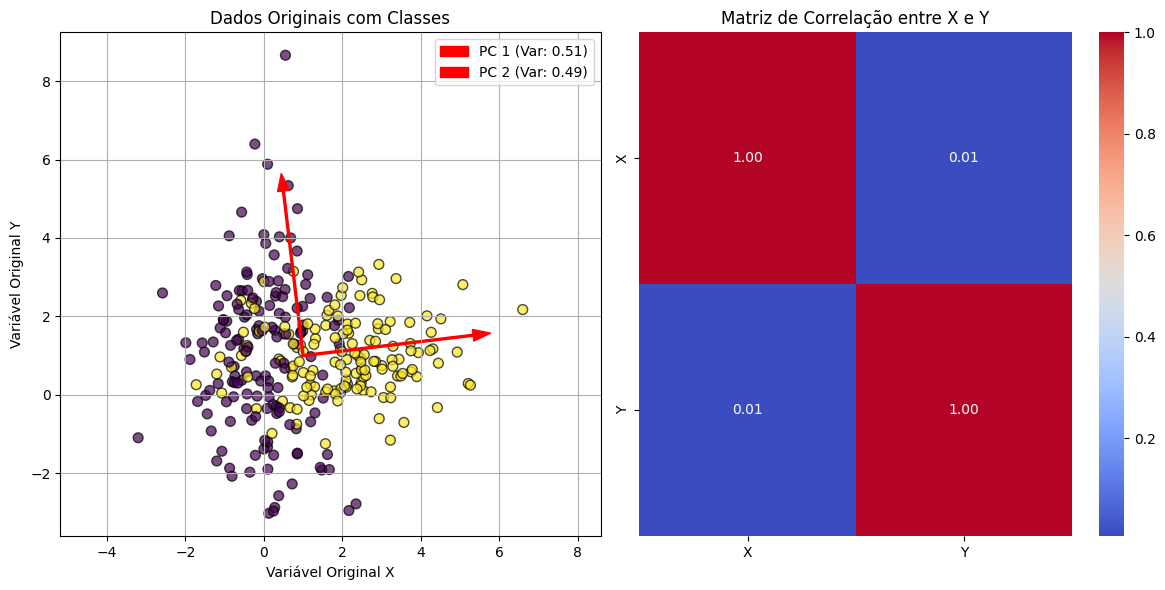

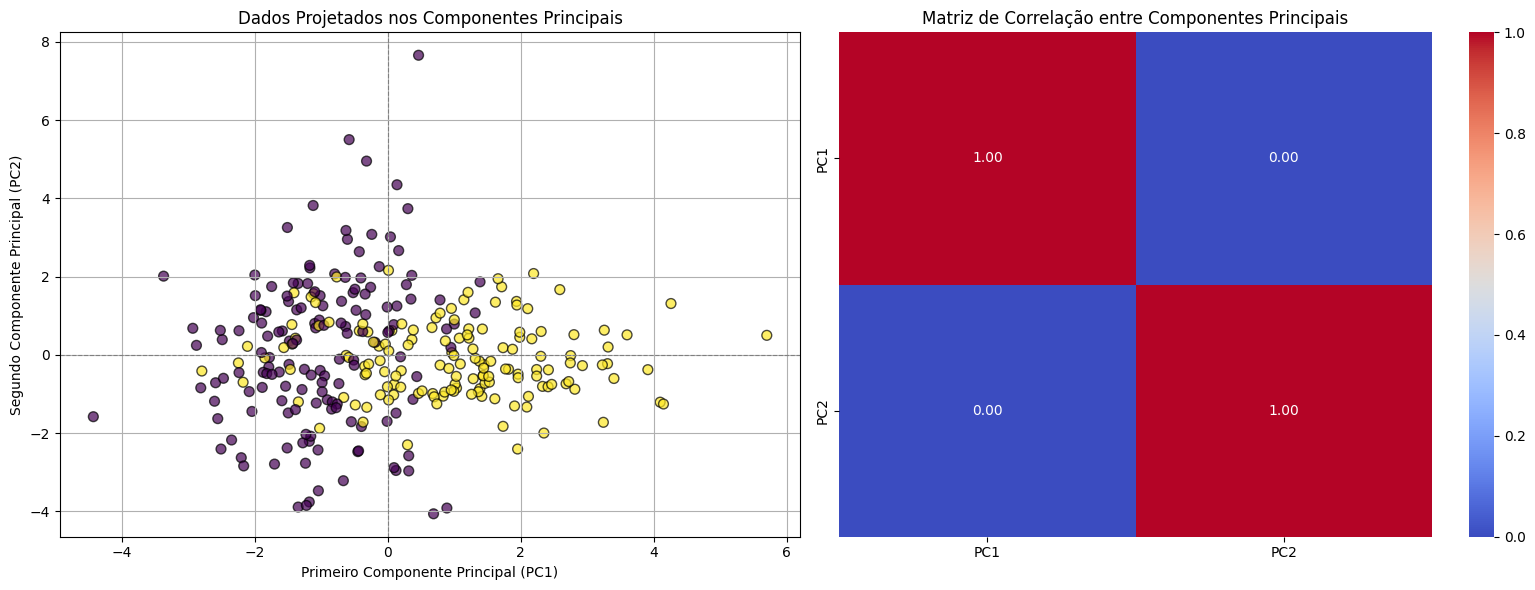

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
import pandas as pd
import seaborn as sns

# 1. Geração de Dados
# Configurações para os blobs
n_samples = 300
random_state = 42

# Definir centros e desvios padrão para cada classe
# Exemplo: duas classes
centers = [
    [0, 1],   # Centro da classe 0
    [2, 1]    # Centro da classe 1
]

# Desvios padrão para x e y de cada classe
# Formato: [[std_x_class0, std_y_class0], [std_x_class1, std_y_class1]]
cluster_std = [
    [1.0, 2.0],  # Desvio padrão da classe 0 (x e y)
    [1.5, 1.0]   # Desvio padrão da classe 1 (x e y)
]

# Ajustar make_blobs para usar cluster_std customizados por classe
# make_blobs não permite std por dimensão para cada cluster diretamente.
# Vamos gerar os dados e depois aplicar os desvios padrão individualmente.

X_raw, y = make_blobs(n_samples=n_samples, centers=np.array(centers), cluster_std=1.0, random_state=random_state)

# Agora, ajustamos os desvios padrão por classe e dimensão
X = np.zeros_like(X_raw)
for i in range(len(centers)):
    # Selecionar os pontos da classe atual
    class_mask = (y == i)
    # Subtrair a média original dos blobs gerados e re-escalar
    # Isso é uma aproximação, pois make_blobs já tem um std geral.
    # Para maior controle, gerar distribuições Gaussianas separadas.
    X[class_mask, 0] = (X_raw[class_mask, 0] - np.mean(X_raw[class_mask, 0])) * cluster_std[i][0] + centers[i][0]
    X[class_mask, 1] = (X_raw[class_mask, 1] - np.mean(X_raw[class_mask, 1])) * cluster_std[i][1] + centers[i][1]

print(f"Dados gerados com {len(np.unique(y))} classes e {n_samples} amostras.")

# 2. Aplicar PCA
pca = PCA(n_components=2)
pca_proj = pca.fit_transform(X)
pcsl = pca.components_

print(f"Componentes principais (vetores):\n{pcsl}")
print(f"Variância explicada por componente:\n{pca.explained_variance_ratio_}")

# 3. Plots

# Plot 1: Dados originais com vetores dos componentes principais
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, alpha=0.7, edgecolors='k')
plt.xlabel('Variável Original X')
plt.ylabel('Variável Original Y')
plt.title('Dados Originais com Classes')
plt.grid(True)

# Adicionar os vetores dos componentes principais normalizados
# Multiplicamos pelos desvios padrão para visualização no scale dos dados
# O PCA já retorna os componentes como vetores unitários na direção da máxima variância.
# Para visualização, podemos escalá-los pela raiz da variância explicada
# ou um valor arbitrário para que sejam visíveis.

scale_factor = 3 * np.sqrt(pca.explained_variance_)

for i, (component, variance) in enumerate(zip(pcsl, pca.explained_variance_)):
    # O vetor é a direção. Plotamos a partir da média dos dados
    mean_x = np.mean(X[:, 0])
    mean_y = np.mean(X[:, 1])
    plt.arrow(mean_x, mean_y, component[0] * scale_factor[i], component[1] * scale_factor[i],
              color='red', width=0.05, head_width=0.3, length_includes_head=True,
              label=f'PC {i+1} (Var: {pca.explained_variance_ratio_[i]:.2f})')

plt.legend()
plt.axis('equal') # Garante que os eixos tenham a mesma escala para a percepção de angulos

# Plot 2: Matriz de Correlação dos Dados Originais
plt.subplot(1, 2, 2)
df = pd.DataFrame(X, columns=['X', 'Y'])
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre X e Y')
plt.tight_layout()
plt.show()

# Plots 3 e 4: Dados projetados nos componentes principais e sua matriz de correlação
plt.figure(figsize=(16, 6)) # Aumenta o tamanho da figura para acomodar dois subplots

# Plot 3: Dados projetados nos componentes principais
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, primeiro subplot
plt.scatter(pca_proj[:, 0], pca_proj[:, 1], c=y, cmap='viridis', s=50, alpha=0.7, edgecolors='k')
plt.xlabel('Primeiro Componente Principal (PC1)')
plt.ylabel('Segundo Componente Principal (PC2)')
plt.title('Dados Projetados nos Componentes Principais')
plt.grid(True)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Plot 4: Matriz de Correlação dos Componentes Principais
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, segundo subplot
df_pca = pd.DataFrame(pca_proj, columns=['PC1', 'PC2'])
corr_matrix_pca = df_pca.corr()
sns.heatmap(corr_matrix_pca, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre Componentes Principais')

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

In [ ]:

import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

fname = 'drive/MyDrive/Curso Projeto de Bloco: Inteligência Artificial e Machine Learning (GRLCDDR1C1-N2-L2)/dataset_vinhos.csv'

target_col = 'target'
target_col_label='target_label'

cat_cols = ['type']


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split


wine = pd.read_csv(fname, sep=';')

wine['type'] = wine['type'].map({
    'white':0,
    'red': 1,
})


# Re-defining these variables as their original defining cell was not executed
target_col = 'target'
target_col_label='target_label'

# Separate features (X) and target (y)
y = wine[target_col]
X = wine.drop(columns=[target_col, target_col_label])

# Split data into development and validation sets (80/20 ratio)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Data splitting complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

Data splitting complete.
X_train shape: (4256, 12)
X_val shape: (1064, 12)
y_train shape: (4256,)
y_val shape: (1064,)


In [ ]:
PCA?


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)

pc_model = PCA(n_components=X_norm.shape[1], whiten=True).fit(X_norm)
proj_train = pc_model.transform(X_norm)


X_norm = scaler.transform(X_val)
proj_val = pc_model.transform(X_norm)


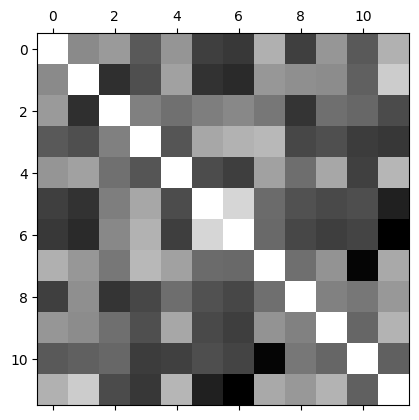

In [ ]:
import matplotlib.pyplot as plt

plt.matshow(X_train.corr(), cmap='gray')


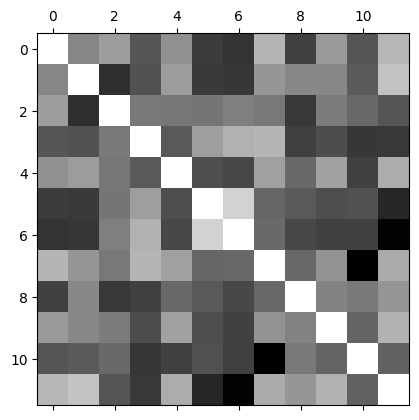

In [ ]:
plt.matshow(np.corrcoef(X_norm.T), cmap='gray')

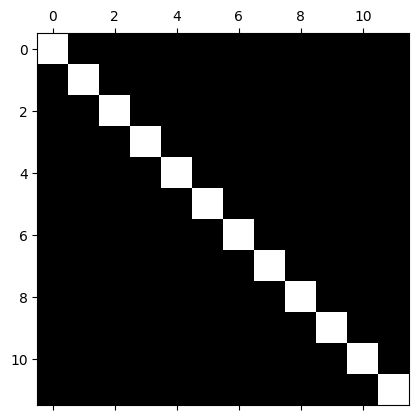

In [ ]:
plt.matshow(np.corrcoef(proj_train.T), cmap='gray')

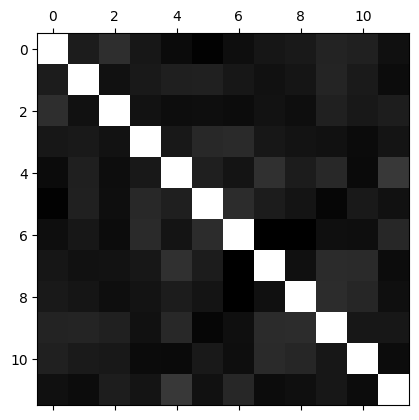

In [ ]:
plt.matshow(np.corrcoef(proj_val.T), cmap='gray')

In [ ]:
pc_model.explained_variance_ratio_

array([9.56268011e-01, 3.85281554e-02, 4.36211800e-03, 4.82754130e-04,
       3.15043089e-04, 2.62584499e-05, 6.20689857e-06, 4.59061243e-06,
       3.81551402e-06, 2.82187148e-06, 2.25372050e-07, 1.25879387e-10])

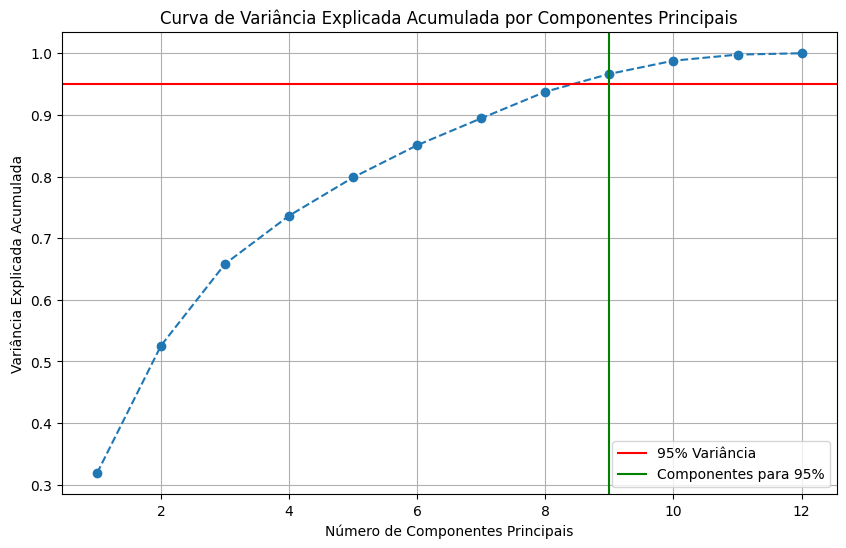

In [ ]:
cumulative_variance_ratio = np.cumsum(pc_model.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='--')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Curva de Variância Explicada Acumulada por Componentes Principais')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variância')
plt.axvline(x=np.argmax(cumulative_variance_ratio >= 0.95) + 1, color='g', linestyle='-', label='Componentes para 95%')
plt.legend()
plt.show()

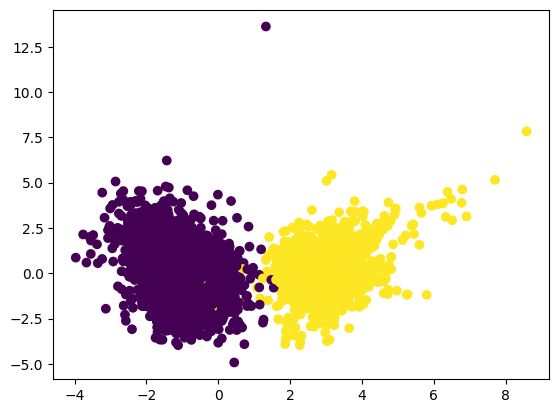

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X_norm = StandardScaler().fit_transform(X_train)

pc_model = PCA(n_components=2).fit(X_norm)
proj = pc_model.transform(X_norm)



plt.scatter(proj[:,0], proj[:,1], c=X_train['type'].tolist())


# Pipeline de ML

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


print("Preprocessing pipeline components (scaler, encoder, preprocessor) created.")
# Instantiate a KNeighborsClassifier with n_neighbors=10
knn_classifier = KNeighborsClassifier(n_neighbors=10)

# Create a Pipeline that combines the preprocessor and the kNN classifier
# This step needs to be re-executed after the preprocessor was updated.
model = Pipeline(steps=[('scaler', StandardScaler()),
                        ('classifier', knn_classifier)])

model.fit(X_train, y_train)
yhat_train = model.predict_proba(X_train)[:,1]
yhat_val = model.predict_proba(X_val)[:,1]


from sklearn import metrics

print(metrics.classification_report(y_train, yhat_train > 0.5))
print(metrics.classification_report(y_val, yhat_val > 0.5))

Preprocessing pipeline components (scaler, encoder, preprocessor) created.
              precision    recall  f1-score   support

           0       0.72      0.71      0.71      1590
           1       0.83      0.83      0.83      2666

    accuracy                           0.79      4256
   macro avg       0.77      0.77      0.77      4256
weighted avg       0.79      0.79      0.79      4256

              precision    recall  f1-score   support

           0       0.66      0.64      0.65       398
           1       0.79      0.81      0.80       666

    accuracy                           0.74      1064
   macro avg       0.73      0.72      0.73      1064
weighted avg       0.74      0.74      0.74      1064



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


print("Preprocessing pipeline components (scaler, encoder, preprocessor) created.")
# Instantiate a KNeighborsClassifier with n_neighbors=10
knn_classifier = KNeighborsClassifier(n_neighbors=10)

# Create a Pipeline that combines the preprocessor and the kNN classifier
# This step needs to be re-executed after the preprocessor was updated.
model = Pipeline(steps=[('scaler', StandardScaler()),
                        ('pca', PCA(n_components=3)),
                        ('classifier', knn_classifier)])

model.fit(X_train, y_train)
yhat_train = model.predict_proba(X_train)[:,1]
yhat_val = model.predict_proba(X_val)[:,1]


from sklearn import metrics

print(metrics.classification_report(y_train, yhat_train > 0.5))
print(metrics.classification_report(y_val, yhat_val > 0.5))

Preprocessing pipeline components (scaler, encoder, preprocessor) created.
              precision    recall  f1-score   support

           0       0.65      0.65      0.65      1590
           1       0.79      0.79      0.79      2666

    accuracy                           0.74      4256
   macro avg       0.72      0.72      0.72      4256
weighted avg       0.74      0.74      0.74      4256

              precision    recall  f1-score   support

           0       0.59      0.57      0.58       398
           1       0.75      0.76      0.75       666

    accuracy                           0.69      1064
   macro avg       0.67      0.67      0.67      1064
weighted avg       0.69      0.69      0.69      1064



              precision    recall  f1-score   support

           0       0.72      0.70      0.71      1590
           1       0.83      0.84      0.83      2666

    accuracy                           0.79      4256
   macro avg       0.77      0.77      0.77      4256
weighted avg       0.79      0.79      0.79      4256

              precision    recall  f1-score   support

           0       0.65      0.64      0.64       398
           1       0.79      0.80      0.79       666

    accuracy                           0.74      1064
   macro avg       0.72      0.72      0.72      1064
weighted avg       0.74      0.74      0.74      1064



('pca', PCA(n_components=3))

In [ ]:
cumulative_variance_ratio

array([0.95626801, 0.99479617, 0.99915828, 0.99964104, 0.99995608,
       0.99998234, 0.99998855, 0.99999314, 0.99999695, 0.99999977,
       1.        , 1.        ])

# Base de Textos

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split


fname = 'drive/MyDrive/Curso Projeto de Bloco: Inteligência Artificial e Machine Learning (GRLCDDR1C1-N2-L2)/Fake.br/pre-processed.csv'

docs = pd.read_csv(fname)

docs['target'] = docs['label'].map({
    'fake': 1,
    'true': 0,
})


# Re-defining these variables as their original defining cell was not executed
target_col = 'target'
target_col_label='label'

# Separate features (X) and target (y)
y = docs[target_col]
X = docs.drop(columns=[target_col, target_col_label])

# Split data into development and validation sets (80/20 ratio)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Data splitting complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")



Data splitting complete.
X_train shape: (5760, 2)
X_val shape: (1440, 2)
y_train shape: (5760,)
y_val shape: (1440,)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    token_pattern=r"(?u)\b[A-Za-z]+\b",
    max_df=0.95,
    min_df=0.05,
    # stop_words='portuguese'
)
trn_vec = vectorizer.fit_transform(X_train['preprocessed_news'])
val_vec = vectorizer.transform(X_val['preprocessed_news'])

In [ ]:

pc_model = PCA(n_components=800).fit(trn_vec)

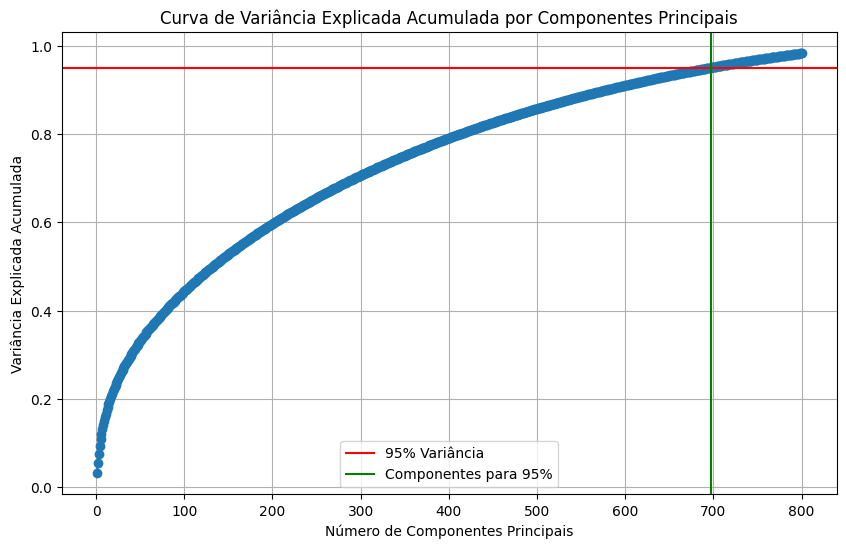

In [ ]:
cumulative_variance_ratio = np.cumsum(pc_model.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, marker='o', linestyle='--')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Curva de Variância Explicada Acumulada por Componentes Principais')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Variância')
plt.axvline(x=np.argmax(cumulative_variance_ratio >= 0.95) + 1, color='g', linestyle='-', label='Componentes para 95%')
plt.legend()
plt.show()

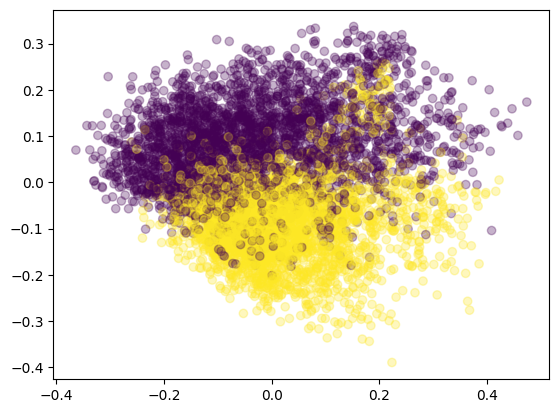

In [ ]:

pc_model = PCA(n_components=5).fit(trn_vec)
proj = pc_model.transform(trn_vec)

plt.scatter(proj[:,2], proj[:,3], c=y_train.tolist(),alpha=0.3)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


print("Preprocessing pipeline components (scaler, encoder, preprocessor) created.")
# Instantiate a KNeighborsClassifier with n_neighbors=10
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Create a Pipeline that combines the preprocessor and the kNN classifier
# This step needs to be re-executed after the preprocessor was updated.
model = Pipeline(steps=[('classifier', knn_classifier)])

model.fit(trn_vec, y_train)
yhat_train = model.predict_proba(trn_vec)[:,1]
yhat_val = model.predict_proba(val_vec)[:,1]


from sklearn import metrics

print(metrics.classification_report(y_train, yhat_train > 0.5))
print(metrics.classification_report(y_val, yhat_val > 0.5))

Preprocessing pipeline components (scaler, encoder, preprocessor) created.
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      2880
           1       0.96      0.77      0.86      2880

    accuracy                           0.87      5760
   macro avg       0.89      0.87      0.87      5760
weighted avg       0.89      0.87      0.87      5760

              precision    recall  f1-score   support

           0       0.70      0.94      0.80       720
           1       0.91      0.59      0.72       720

    accuracy                           0.77      1440
   macro avg       0.81      0.77      0.76      1440
weighted avg       0.81      0.77      0.76      1440



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


print("Preprocessing pipeline components (scaler, encoder, preprocessor) created.")
# Instantiate a KNeighborsClassifier with n_neighbors=10
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Create a Pipeline that combines the preprocessor and the kNN classifier
# This step needs to be re-executed after the preprocessor was updated.
model = Pipeline(steps=[
  ('pca', PCA(n_components=700)),
  ('classifier', knn_classifier)])

model.fit(trn_vec, y_train)
yhat_train = model.predict_proba(trn_vec)[:,1]
yhat_val = model.predict_proba(val_vec)[:,1]


from sklearn import metrics

print(metrics.classification_report(y_train, yhat_train > 0.5))
print(metrics.classification_report(y_val, yhat_val > 0.5))

Preprocessing pipeline components (scaler, encoder, preprocessor) created.
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      2880
           1       0.96      0.77      0.85      2880

    accuracy                           0.87      5760
   macro avg       0.88      0.87      0.87      5760
weighted avg       0.88      0.87      0.87      5760

              precision    recall  f1-score   support

           0       0.70      0.95      0.80       720
           1       0.92      0.59      0.72       720

    accuracy                           0.77      1440
   macro avg       0.81      0.77      0.76      1440
weighted avg       0.81      0.77      0.76      1440



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


print("Preprocessing pipeline components (scaler, encoder, preprocessor) created.")
# Instantiate a KNeighborsClassifier with n_neighbors=10
tree_classifier = DecisionTreeClassifier(max_depth=4)

# Create a Pipeline that combines the preprocessor and the kNN classifier
# This step needs to be re-executed after the preprocessor was updated.
model = Pipeline(steps=[
  ('pca', PCA(n_components=700)),
  ('classifier', tree_classifier)])

model.fit(trn_vec, y_train)
yhat_train = model.predict_proba(trn_vec)[:,1]
yhat_val = model.predict_proba(val_vec)[:,1]


from sklearn import metrics

print(metrics.classification_report(y_train, yhat_train > 0.5))
print(metrics.classification_report(y_val, yhat_val > 0.5))

Preprocessing pipeline components (scaler, encoder, preprocessor) created.
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      2880
           1       0.89      0.93      0.91      2880

    accuracy                           0.91      5760
   macro avg       0.91      0.91      0.91      5760
weighted avg       0.91      0.91      0.91      5760

              precision    recall  f1-score   support

           0       0.90      0.86      0.88       720
           1       0.87      0.90      0.89       720

    accuracy                           0.88      1440
   macro avg       0.88      0.88      0.88      1440
weighted avg       0.88      0.88      0.88      1440



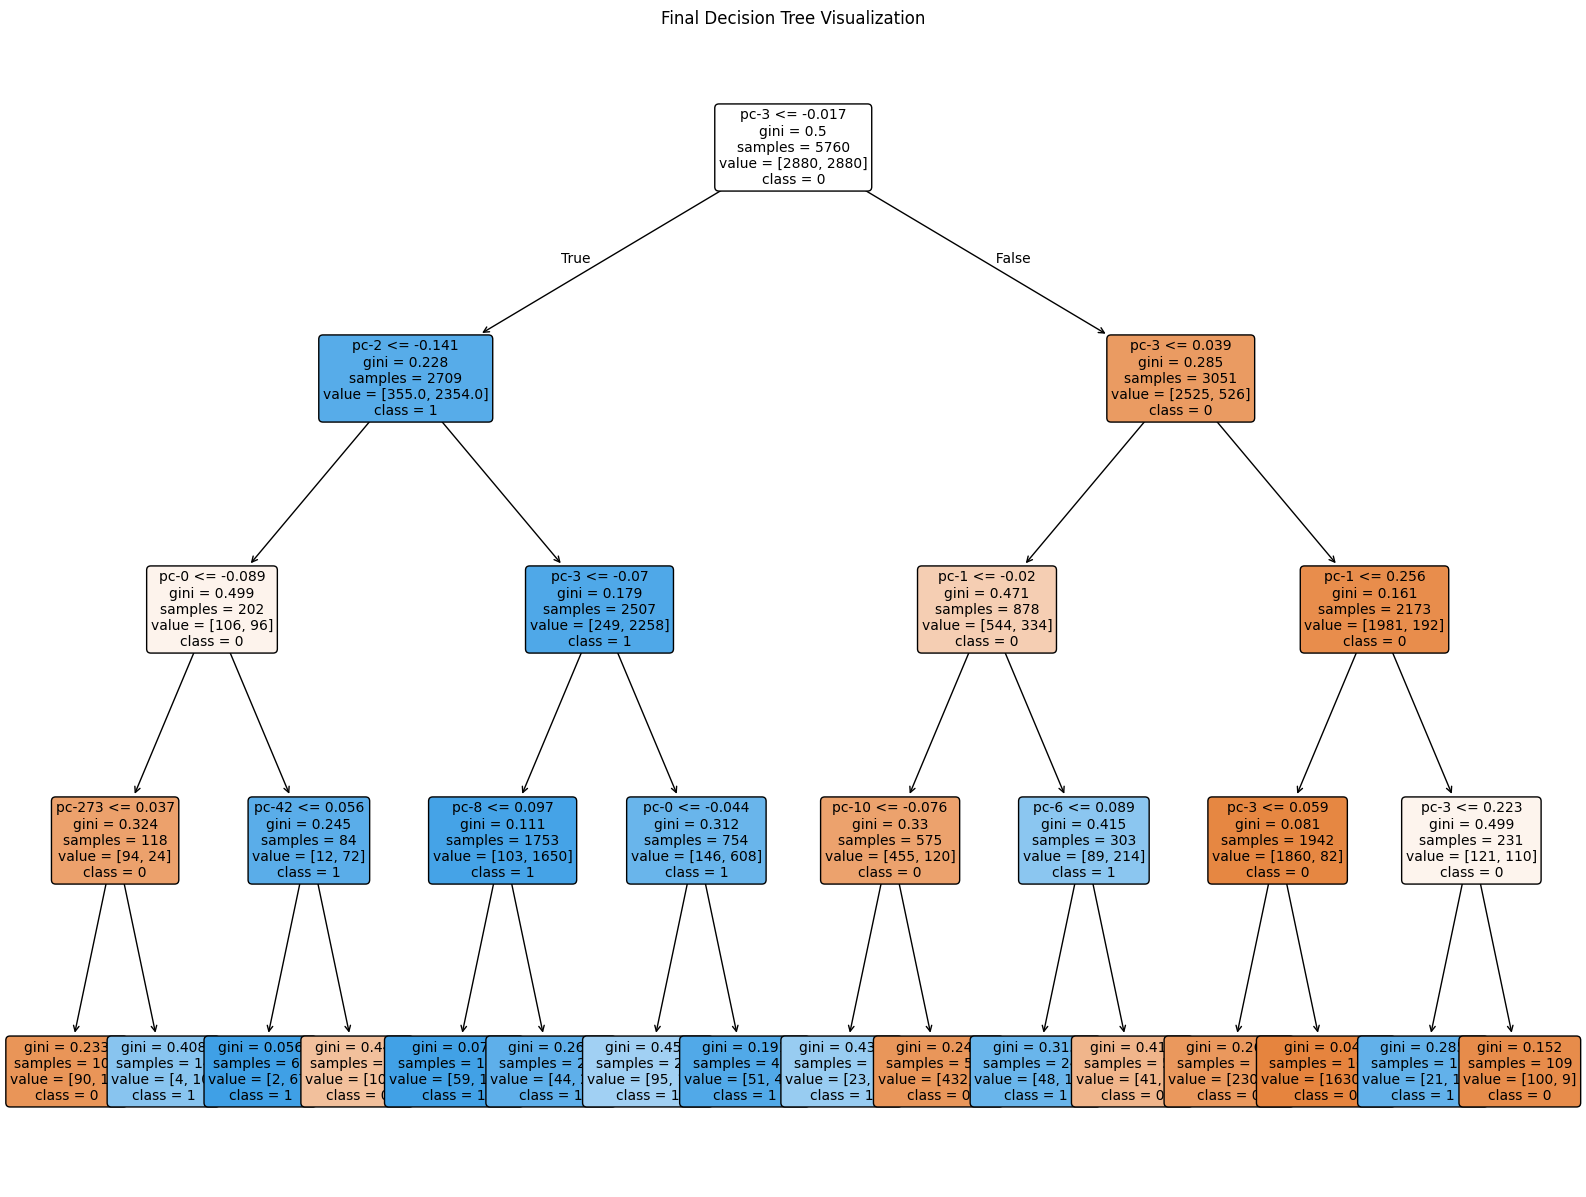

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get the trained DecisionTreeClassifier from the pipeline
decision_tree_classifier = model.named_steps['classifier']

# Get feature names used by the tree (numerical + categorical after encoding)
# The preprocessor applies StandardScaler to num_cols and OrdinalEncoder to cat_cols
# The tree will receive these features in that order.
# For simplicity, we'll use the original feature names. Note that if one-hot encoding was used,
# the feature names would need to reflect the expanded columns.
feature_names_for_tree = [f'pc-{i}' for i in range(700)]



# Get class names (assuming 0 and 1 are the target classes)
class_names = [str(c) for c in sorted(y_train.unique())]

plt.figure(figsize=(20, 15))
plot_tree(decision_tree_classifier,
          feature_names=feature_names_for_tree,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Final Decision Tree Visualization')
plt.show()

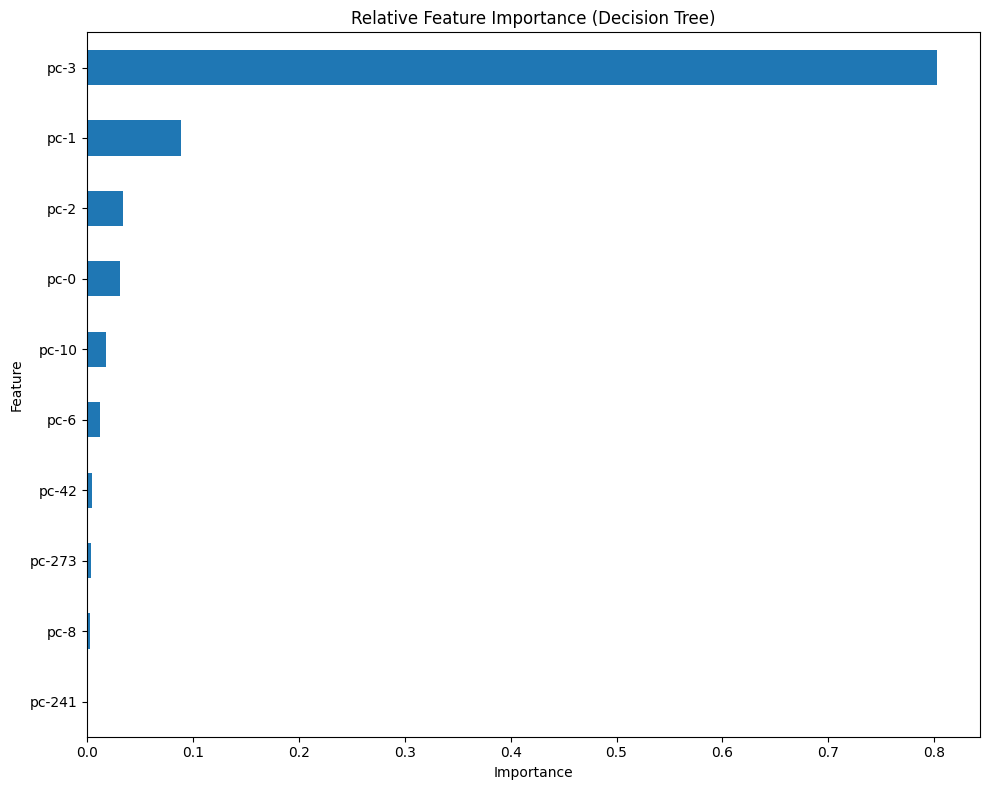

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances from the trained Decision Tree classifier
feature_importances = model.steps[1][1].feature_importances_

# Get feature names in the correct order
# The preprocessor first processes numerical columns, then categorical columns
feature_names = [f'pc-{i}' for i in range(700)]


# Create a Pandas Series for easier handling and sorting
feature_importance_series = pd.Series(feature_importances, index=feature_names)

# Sort features by importance in descending order
sorted_importance = feature_importance_series.sort_values(ascending=True)

# Create the horizontal bar plot
plt.figure(figsize=(10, 8))
sorted_importance.tail(10).plot(kind='barh')
plt.title('Relative Feature Importance (Decision Tree)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()